# Day 3 — Aggregation & Visualization

Goal: Answer simple questions with pandas and create two plots.

Tasks: Top items by revenue, revenue by date (time series). Questions will be defined after day 2.

In [1]:
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')

csv_path = Path('clean_data.csv')
if not csv_path.exists():
    # create a small sample CSV so the notebook can run without the real data
    sample = [
        {'scraped_at': '2026-06-30T12:00:00', 'item': 'Croissant', 'price': 2.5, 'quantity': 1, 'total': 2.5, 'store': 'Main', 'url': 'u1'},
        {'scraped_at': '2026-06-30T12:05:00', 'item': 'Baguette', 'price': 3.0, 'quantity': 2, 'total': 6.0, 'store': 'Main', 'url': 'u2'},
        {'scraped_at': '2026-07-01T09:00:00', 'item': 'Croissant', 'price': 2.5, 'quantity': 3, 'total': 7.5, 'store': 'Branch', 'url': 'u3'}
    ]
    pd.DataFrame(sample).to_csv(csv_path, index=False, encoding='utf-8')
    print('Wrote sample sales_clean.csv - replace with your real file')

# Read the CSV, parse scraped_at as datetime if present
df = pd.read_csv(csv_path, parse_dates=['scraped_at'], encoding='utf-8')
print('Loaded rows:', len(df))
print('Column types:')
print(df.dtypes)


Loaded rows: 570
Column types:
name                             str
hash_name                        str
wear                             str
url                              str
price_usd                    float64
quantity                       int64
scraped_at            datetime64[us]
total market value           float64
dtype: object


## Top skins by market value (cost of all the skins combined)
Group by `name` and sum `price_usd`. Save top 5 as a bar chart (horizontal).

Top 5 Items by Market Value:
                               name  market_value
     AK-47 | Redline (Field-Tested)      46917.53
 AK-47 | Inheritance (Field-Tested)      42108.57
AK-47 | Blue Laminate (Factory New)      37436.28
   AK-47 | Nightwish (Field-Tested)      35016.96
   AK-47 | Aphrodite (Minimal Wear)      34465.20
Saved plot: top5_items.png


/var/folders/yq/t6hy0qgd0yd2g86b0t160np40000gn/T/ipykernel_67930/1021623377.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='market_value', y='name', palette='viridis')


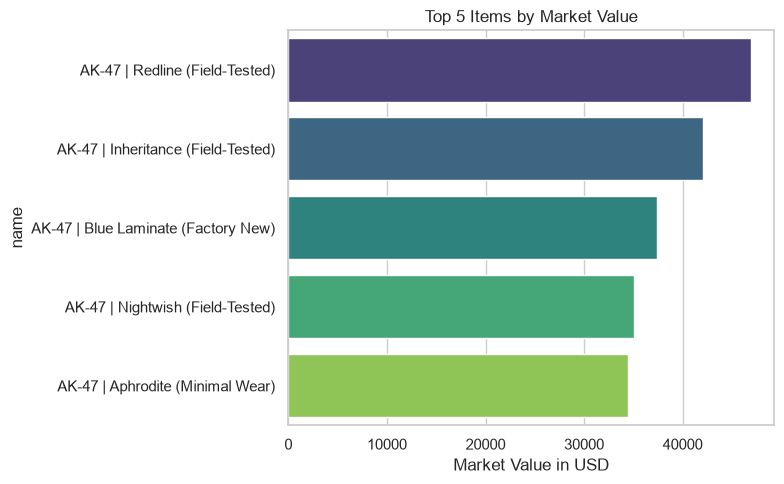

In [3]:
# check whether price_usd even exists before calculating with it
if 'price_usd' not in df.columns:
    print("there are no prices")

# market_value per row: price times number of active listings
df['market_value'] = df['price_usd'] * df['quantity']

# group by name and sum market_value, then sort descending
top_names = df.groupby('name', as_index=False)['market_value'].sum()
top_names = top_names.sort_values('market_value', ascending=False)
top5 = top_names.head(5)   # keep only the five highest values

print('Top 5 Items by Market Value:')
print(top5.to_string(index=False))

# horizontal bar chart, one bar per item, sorted by value
plt.figure(figsize=(8, 5))
sns.barplot(data=top5, x='market_value', y='name', palette='viridis')
plt.title('Top 5 Items by Market Value')
plt.xlabel('Market Value in USD')
plt.tight_layout()
plt.savefig('top5_items.png')   # save the chart as an image file
print('Saved plot: top5_items.png')
plt.show()

## Skins per wear
Group by wear and plot a line chart showing how many skins fall into each wear category.

Number of Skins per Wear:
          wear  count
Battle-Scarred    104
   Factory New    107
  Field-Tested    126
  Minimal Wear    124
     Well-Worn    109
Saved plot: skins_per_wear.png


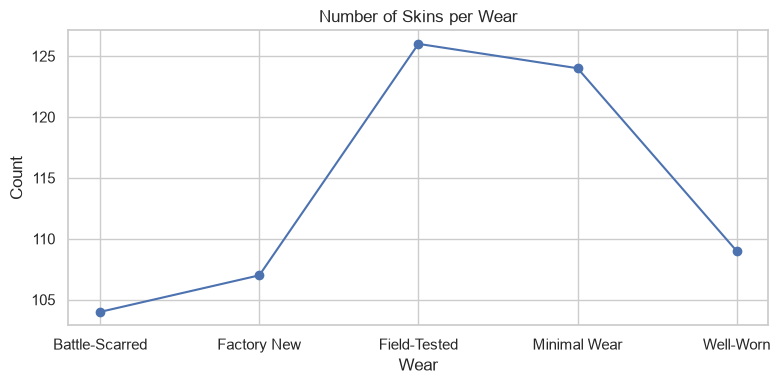

In [4]:
wear_counts = df.groupby('wear', as_index=False)['name'].count()
wear_counts = wear_counts.rename(columns={'name': 'count'})

print('Number of Skins per Wear:')
print(wear_counts.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(wear_counts['wear'], wear_counts['count'], marker='o', linestyle='-')
plt.title('Number of Skins per Wear')
plt.xlabel('Wear')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('skins_per_wear.png')
print('Saved plot: skins_per_wear.png')
plt.show()